# Model Training

Notebook này thực hiện: load features → split → integrity check → scaling.
Các bước training, threshold tuning và evaluation sẽ nối tiếp bên dưới.

## 1. Setup

Question: Notebook đang dùng input nào và quy ước chia dữ liệu ra sao?

In [2]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

ID_COL = "CONS_NO"
TARGET_COL = "FLAG"

RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

print(f"Features path: {FEATURES_PATH}")
print(f"Split ratio: train={TRAIN_SIZE:.0%}, validation={VALIDATION_SIZE:.0%}, test={TEST_SIZE:.0%}")
print("Note: stratify=y is used to keep the Normal/Theft ratio similar in all splits.")

Features path: d:\UIT\PROJECT\MACHINE-LEARNING-PROJECT\CS114----ML-Project---Energy-Theft-Detection\data\processed\features.csv
Split ratio: train=70%, validation=15%, test=15%
Note: stratify=y is used to keep the Normal/Theft ratio similar in all splits.


## 2. Load Features

Question: `features.csv` có đủ `CONS_NO`, `FLAG` và các feature dùng cho model không?

In [3]:
if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {FEATURES_PATH}. Hãy chạy preprocessing_v2.py và feature.py trước."
    )

df = pd.read_csv(FEATURES_PATH)

required_cols = {ID_COL, TARGET_COL}
missing_required_cols = required_cols - set(df.columns)
if missing_required_cols:
    raise ValueError(f"features.csv thiếu cột bắt buộc: {missing_required_cols}")

feature_cols = [col for col in df.columns if col not in [ID_COL, TARGET_COL]]

X = df[feature_cols].copy()
y = df[TARGET_COL].astype(int).copy()
ids = df[ID_COL].copy()

print(f"Dataset shape: {df.shape[0]:,} customers x {df.shape[1]:,} columns")
print(f"Number of model features: {len(feature_cols):,}")
print(f"Target distribution:")
display(y.value_counts().rename(index={0: "Normal", 1: "Theft"}).to_frame("count"))

print("Note: CONS_NO is kept only for tracking customers, not as a model feature.")

Dataset shape: 42,372 customers x 163 columns
Number of model features: 161
Target distribution:


,count
FLAG,
Normal,38757
Theft,3615


Note: CONS_NO is kept only for tracking customers, not as a model feature.


## 3. Train / Validation / Test Split

Question: Chia dữ liệu như thế nào để mỗi split vẫn giữ tỷ lệ `Normal` và `Theft` gần giống dataset gốc?

In [4]:
temp_size = VALIDATION_SIZE + TEST_SIZE
relative_test_size = TEST_SIZE / temp_size

X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(
    X,
    y,
    ids,
    test_size=temp_size,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(
    X_temp,
    y_temp,
    ids_temp,
    test_size=relative_test_size,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

ids_train = ids_train.reset_index(drop=True)
ids_val = ids_val.reset_index(drop=True)
ids_test = ids_test.reset_index(drop=True)

print("Split completed.")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Split completed.
X_train: (29660, 161), y_train: (29660,)
X_val:   (6356, 161), y_val:   (6356,)
X_test:  (6356, 161), y_test:  (6356,)


## 4. Split Check

Question: Sau khi split, tỷ lệ `Theft` trong train/validation/test có còn gần giống nhau không?

In [5]:
def summarize_split(name: str, y_split: pd.Series) -> dict:
    counts = y_split.value_counts().sort_index()
    normal_count = counts.get(0, 0)
    theft_count = counts.get(1, 0)
    total = len(y_split)

    return {
        "split": name,
        "total": total,
        "Normal count": normal_count,
        "Theft count": theft_count,
        "Normal ratio": normal_count / total,
        "Theft ratio": theft_count / total,
    }

split_report = pd.DataFrame(
    [
        summarize_split("full", y),
        summarize_split("train", y_train),
        summarize_split("validation", y_val),
        summarize_split("test", y_test),
    ]
)

display(
    split_report.style.format(
        {
            "Normal ratio": "{:.2%}",
            "Theft ratio": "{:.2%}",
        }
    )
)

print("Observation: Nếu các Theft ratio gần bằng nhau, stratified split đã hoạt động đúng.")

,split,total,Normal count,Theft count,Normal ratio,Theft ratio
0,full,42372,38757,3615,91.47%,8.53%
1,train,29660,27130,2530,91.47%,8.53%
2,validation,6356,5813,543,91.46%,8.54%
3,test,6356,5814,542,91.47%,8.53%


Observation: Nếu các Theft ratio gần bằng nhau, stratified split đã hoạt động đúng.


## 5. Split Integrity Check

Question: Có customer nào bị trùng lặp giữa các split không? Tổng số row có khớp không?

In [6]:
assert len(X_train) + len(X_val) + len(X_test) == len(X), (
    f"Row count mismatch: {len(X_train)} + {len(X_val)} + {len(X_test)} != {len(X)}"
)

assert ids_train.isin(ids_val).sum() == 0, "Overlap detected: train ∩ validation"
assert ids_train.isin(ids_test).sum() == 0, "Overlap detected: train ∩ test"
assert ids_val.isin(ids_test).sum() == 0, "Overlap detected: validation ∩ test"

print("Split integrity check passed: no customer overlap and row counts match.")

Split integrity check passed: no customer overlap and row counts match.


## 6. Feature Scaling

Question: Scaler phải được fit ở đâu để tránh data leakage?

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=feature_cols,
).reset_index(drop=True)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=feature_cols,
).reset_index(drop=True)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
).reset_index(drop=True)

print("Scaling completed: scaler fitted on train only, then applied to validation and test.")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaling completed: scaler fitted on train only, then applied to validation and test.
X_train_scaled: (29660, 161)
X_val_scaled:   (6356, 161)
X_test_scaled:  (6356, 161)


## 7. Shared Variables for Model Training

Các biến chung mà cả 3 thành viên sẽ dùng để train model:

| Biến | Mô tả |
|---|---|
| `X_train_scaled`, `X_val_scaled`, `X_test_scaled` | Feature đã chuẩn hóa |
| `y_train`, `y_val`, `y_test` | Nhãn (0 = Normal, 1 = Theft) |
| `ids_train`, `ids_val`, `ids_test` | CONS_NO, chỉ dùng tracking |

**Lưu ý:**
- `CONS_NO` chỉ dùng để tracking khách hàng, **không** dùng làm feature cho model.
- **Test set chỉ dùng cho final evaluation**, không dùng để chọn model hay tuning threshold.
- Dùng validation set để so sánh model và chọn threshold.

## 8. Evaluation Helper Functions

Vì SGCC Electricity Theft Dataset là dữ liệu mất cân bằng, **Accuracy không nên được dùng làm metric chính**.  
Một mô hình có thể đạt Accuracy cao nếu dự đoán phần lớn khách hàng là normal, nhưng vẫn bỏ sót nhiều khách hàng theft.

Do đó, project này ưu tiên các metric sau:

- **Recall**: đo trong số các khách hàng theft thật, mô hình phát hiện đúng được bao nhiêu.
- **F1-score**: cân bằng giữa Precision và Recall.
- **PR-AUC**: phù hợp hơn khi class dương, tức class theft, chiếm tỷ lệ nhỏ trong dataset.

Trong bài toán phát hiện trộm điện, **False Negative** là lỗi đặc biệt quan trọng.  
False Negative xảy ra khi khách hàng thật sự theft nhưng mô hình lại dự đoán là normal.

Để tránh data leakage, việc chọn model và tune threshold chỉ nên thực hiện trên validation set.  
Test set chỉ nên được dùng một lần ở bước đánh giá cuối cùng sau khi model và threshold đã được chọn.

In [8]:
# STEP 8: Evaluation Helper Functions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def get_predictions_at_threshold(y_prob, threshold):
    """
    Chuyển xác suất dự đoán thành nhãn nhị phân dựa trên một threshold cho trước.

    Tham số
    -------
    y_prob : array-like
        Xác suất dự đoán cho class dương, trong project này là class 1 = theft.
    threshold : float
        Ngưỡng phân loại. Nếu xác suất >= threshold thì dự đoán là 1, ngược lại là 0.

    Trả về
    ------
    np.ndarray
        Nhãn dự đoán nhị phân: 0 = normal, 1 = theft.
    """
    y_prob = np.asarray(y_prob)
    return (y_prob >= threshold).astype(int)


def evaluate_binary_classifier(y_true, y_prob, threshold=0.5):
    """
    Đánh giá mô hình binary classification dựa trên xác suất dự đoán và threshold.

    Các metric được tính:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC
    - PR-AUC

    Trong đó:
    -------
    ROC-AUC và PR-AUC được tính trực tiếp từ xác suất dự đoán, không dùng nhãn đã threshold.
    Accuracy, Precision, Recall và F1-score được tính từ nhãn dự đoán sau khi áp dụng threshold.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    y_pred = get_predictions_at_threshold(y_prob, threshold)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    return metrics


def plot_confusion_matrix_custom(y_true, y_pred, title):
    """
    Vẽ confusion matrix cho bài toán binary classification.

    Ý nghĩa nhãn:
    - 0 = normal customer
    - 1 = theft customer
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Normal (0)", "Theft (1)"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format="d", colorbar=False)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()
    plt.show()

    return cm


def collect_result_row(model_name, split_name, y_true, y_prob, threshold):
    """
    Gom kết quả đánh giá mô hình thành một dictionary phù hợp để tạo bảng báo cáo.

    Tham số
    -------
    model_name : str
        Tên mô hình, ví dụ: "Logistic Regression Baseline".
    split_name : str
        Tên tập dữ liệu được đánh giá, ví dụ: "Validation" hoặc "Test".
    y_true : array-like
        Nhãn thật.
    y_prob : array-like
        Xác suất dự đoán cho class 1.
    threshold : float
        Ngưỡng phân loại dùng để chuyển xác suất thành nhãn 0/1.

    Trả về
    ------
    dict
        Một dòng kết quả gồm tên mô hình, tên split, threshold và các metric đánh giá.
    """
    metrics = evaluate_binary_classifier(
        y_true=y_true, y_prob=y_prob, threshold=threshold
    )

    row = {
        "model": model_name,
        "split": split_name,
        "threshold": metrics["threshold"],
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    }

    return row

### Ghi chú sử dụng

Các helper function trong bước này sẽ được dùng lại ở những bước sau:

- Logistic Regression baseline
- Logistic Regression với L2 regularization
- Gaussian Discriminant Analysis
- Linear Regression baseline cho mục đích so sánh
- Các model mở rộng nếu cần, ví dụ Random Forest, XGBoost hoặc LightGBM
- Threshold tuning trên validation set
- Đánh giá cuối cùng trên test set
- Phân tích confusion matrix
- Tạo bảng so sánh model để đưa vào báo cáo

Nguyên tắc quan trọng:

**Không tune threshold trên test set.**  
Validation set được dùng để chọn threshold và model phù hợp.  
Test set chỉ dùng sau cùng để đánh giá khả năng generalization của model đã chọn.

## 9. Logistic Regression Baseline

Logistic Regression là mô hình phù hợp cho bài toán **binary classification** vì mô hình trực tiếp ước lượng xác suất một mẫu thuộc class dương:

- `0 = normal customer`
- `1 = theft customer`

Trong bước này, ta train **Logistic Regression baseline** để tạo kết quả tham chiếu ban đầu.  
Baseline này được thiết kế đơn giản nhất có thể: nếu phiên bản `sklearn` hỗ trợ, mô hình sẽ không dùng regularization.

Mục tiêu của baseline là trả lời câu hỏi:

> Với các feature hiện tại, một mô hình Logistic Regression cơ bản có thể phát hiện theft tốt đến mức nào?

Ở bước này, ta chỉ đánh giá trên **validation set** với threshold mặc định `0.5`.  
**Test set chưa được sử dụng** để tránh data leakage. Test set chỉ nên dùng ở bước đánh giá cuối cùng sau khi đã chọn model và threshold.

In [9]:
# STEP 9: Logistic Regression Baseline

from sklearn.linear_model import LogisticRegression

# 9.1. Train Logistic Regression baseline

"""
Baseline này ưu tiên không dùng regularization.
Một số phiên bản sklearn hỗ trợ penalty=None, trong khi một số phiên bản cũ hơn dùng penalty="none".
"""
try:
    logreg_baseline = LogisticRegression(
        penalty=None, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    logreg_baseline.fit(X_train_scaled, y_train)

except Exception as error:
    print("penalty=None không được hỗ trợ trong phiên bản sklearn hiện tại.")
    print("Chuyển sang fallback: penalty='none'")
    print(f"Lỗi gốc: {error}")

    logreg_baseline = LogisticRegression(
        penalty="none", solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    logreg_baseline.fit(X_train_scaled, y_train)


# 9.2. Predict probability trên validation set

# predict_proba trả về xác suất cho cả hai class [P(class 0), P(class 1)].
# Ta lấy cột thứ 2 vì class 1 tương ứng với theft customer.
y_val_prob_baseline = logreg_baseline.predict_proba(X_val_scaled)[:, 1]


# 9.3. Evaluate validation set với threshold mặc định 0.5

baseline_threshold = 0.5

baseline_val_row = collect_result_row(
    model_name="Logistic Regression Baseline",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_baseline,
    threshold=baseline_threshold,
)

baseline_val_result_df = pd.DataFrame([baseline_val_row])

baseline_val_result_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression Baseline,Validation,0.5,0.91803,0.61,0.112339,0.189736,0.794605,0.351557


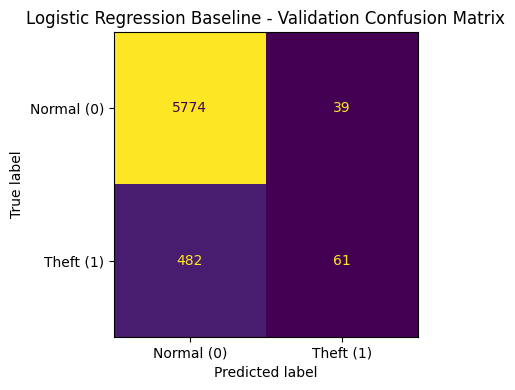

In [10]:
# 9.4. Confusion matrix trên validation set

y_val_pred_baseline = get_predictions_at_threshold(
    y_prob=y_val_prob_baseline, threshold=baseline_threshold
)

baseline_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_baseline,
    title="Logistic Regression Baseline - Validation Confusion Matrix",
)

### Nhận Xét:
+ Logistic Regression baseline đạt Accuracy cao trên validation set, nhưng kết quả này chưa phản ánh tốt khả năng phát hiện theft do dữ liệu bị mất cân bằng. Confusion Matrix cho thấy model dự đoán rất tốt class normal với số False Positive thấp, nhưng bỏ sót phần lớn theft customers.

+ Cụ thể, model chỉ phát hiện được 61 trên tổng số 543 theft customers, tương ứng Recall khoảng 11.23%. Điều này cho thấy threshold mặc định 0.5 chưa phù hợp với bài toán Energy Theft Detection, nơi False Negative là lỗi nguy hiểm nhất.

+ Tuy nhiên, ROC-AUC = 0.7946 và PR-AUC = 0.3516 cho thấy model vẫn có khả năng phân biệt nhất định giữa normal và theft. Vì vậy, các bước tiếp theo cần thử Logistic Regression với L2 regularization và thực hiện threshold tuning trên validation set để cải thiện Recall và F1-score.

## 10. Logistic Regression with L2 Regularization

Ở STEP 9, Logistic Regression baseline cho kết quả Recall khá thấp. Điều này cho thấy với threshold mặc định `0.5`, mô hình còn bỏ sót nhiều khách hàng theft.

Trong bước này, ta train **Logistic Regression với L2 regularization**.

**L2 regularization** là kỹ thuật thêm một thành phần phạt vào loss function để hạn chế hệ số của mô hình trở nên quá lớn. Điều này giúp mô hình ổn định hơn và có thể giảm overfitting.

Tham số `C` trong `LogisticRegression` điều khiển mức độ regularization:

- `C` nhỏ => regularization mạnh hơn
- `C` lớn => regularization yếu hơn
- `C = 1.0` là giá trị mặc định thường dùng

Ta chọn `C` dựa trên **validation set**, không dùng test set.  
Validation set được dùng để lựa chọn hyperparameter, còn test set chỉ dùng ở bước đánh giá cuối cùng sau khi model và threshold đã được chọn.

Vì dataset bị mất cân bằng, ta ưu tiên chọn model theo thứ tự:

1. **PR-AUC**: quan trọng khi class theft chiếm tỷ lệ nhỏ.
2. **F1-score**: cân bằng giữa Precision và Recall.
3. **Recall**: đo khả năng phát hiện đúng các khách hàng theft thật.

Ở bước này, ta vẫn giữ threshold mặc định `0.5`.  
Threshold tuning sẽ được thực hiện ở bước sau.

In [11]:
# STEP 10: Logistic Regression with L2 Regularization

from sklearn.linear_model import LogisticRegression

# 10.1. Khai báo grid các giá trị C cần thử

# C càng nhỏ thì regularization càng mạnh.
# C càng lớn thì regularization càng yếu.
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

l2_result_rows = []
l2_models = {}
l2_val_probabilities = {}

l2_threshold = 0.5


# 10.2. Train và evaluate Logistic Regression L2 cho từng C

for C in C_values:
    model_name = f"Logistic Regression L2 (C={C})"

    logreg_l2 = LogisticRegression(
        penalty="l2", C=C, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    # Train model trên train set.
    logreg_l2.fit(X_train_scaled, y_train)

    # Dự đoán xác suất class 1 = theft trên validation set.
    y_val_prob_l2 = logreg_l2.predict_proba(X_val_scaled)[:, 1]

    # Đánh giá validation set với threshold mặc định 0.5.
    result_row = collect_result_row(
        model_name=model_name,
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_l2,
        threshold=l2_threshold,
    )

    result_row["C"] = C

    l2_result_rows.append(result_row)
    l2_models[C] = logreg_l2
    l2_val_probabilities[C] = y_val_prob_l2


# 10.3. Tạo bảng so sánh validation metrics cho từng C

l2_results_df = pd.DataFrame(l2_result_rows)

# Sắp xếp theo thứ tự ưu tiên:
# 1. pr_auc giảm dần
# 2. f1_score giảm dần
# 3. recall giảm dần
l2_results_df = l2_results_df.sort_values(
    by=["pr_auc", "f1_score", "recall"], ascending=[False, False, False]
).reset_index(drop=True)

l2_results_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,C
0,Logistic Regression L2 (C=100.0),Validation,0.5,0.918030,0.610000,0.112339,0.189736,0.794726,0.351561,100.00
1,Logistic Regression L2 (C=10.0),Validation,0.5,0.918030,0.610000,0.112339,0.189736,0.794507,0.350721,10.00
2,Logistic Regression L2 (C=1.0),Validation,0.5,0.918030,0.617021,0.106814,0.182104,0.793735,0.348345,1.00
3,Logistic Regression L2 (C=0.1),Validation,0.5,0.918030,0.641026,0.092081,0.161031,0.793470,0.346926,0.10
4,Logistic Regression L2 (C=0.01),Validation,0.5,0.917873,0.661538,0.079190,0.141447,0.790166,0.339408,0.01


In [12]:
# 10.4. Chọn best C và best L2 model trên validation set

l2_best_row = l2_results_df.iloc[0].to_dict()

logreg_l2_best_C = l2_best_row["C"]
logreg_l2_best = l2_models[logreg_l2_best_C]
y_val_prob_l2_best = l2_val_probabilities[logreg_l2_best_C]

print("Best Logistic Regression L2 model trên validation set")
print(f"Best C       : {logreg_l2_best_C}")
print(f"PR-AUC       : {l2_best_row['pr_auc']:.6f}")
print(f"F1-score     : {l2_best_row['f1_score']:.6f}")
print(f"Recall       : {l2_best_row['recall']:.6f}")
print(f"Precision    : {l2_best_row['precision']:.6f}")
print(f"Accuracy     : {l2_best_row['accuracy']:.6f}")
print(f"ROC-AUC      : {l2_best_row['roc_auc']:.6f}")

Best Logistic Regression L2 model trên validation set
Best C       : 100.0
PR-AUC       : 0.351561
F1-score     : 0.189736
Recall       : 0.112339
Precision    : 0.610000
Accuracy     : 0.918030
ROC-AUC      : 0.794726


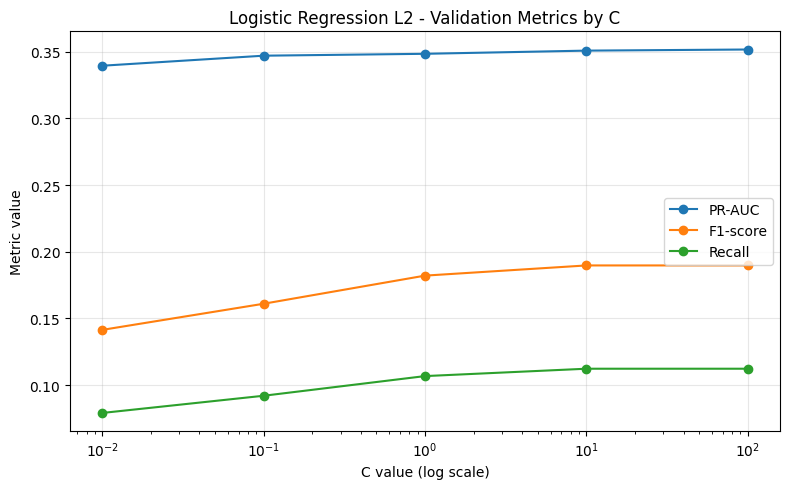

In [13]:
# 10.5. Vẽ biểu đồ PR-AUC, F1-score và Recall theo C

# Để biểu đồ dễ đọc, ta vẽ theo thứ tự C ban đầu thay vì thứ tự đã sort.
l2_plot_df = l2_results_df.sort_values("C").reset_index(drop=True)

plt.figure(figsize=(8, 5))

plt.plot(l2_plot_df["C"], l2_plot_df["pr_auc"], marker="o", label="PR-AUC")

plt.plot(l2_plot_df["C"], l2_plot_df["f1_score"], marker="o", label="F1-score")

plt.plot(l2_plot_df["C"], l2_plot_df["recall"], marker="o", label="Recall")

plt.xscale("log")
plt.xlabel("C value (log scale)")
plt.ylabel("Metric value")
plt.title("Logistic Regression L2 - Validation Metrics by C")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

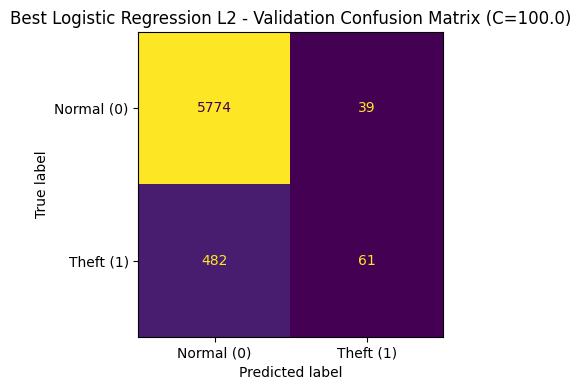

In [14]:
# 10.6. Confusion matrix của best L2 model trên validation set

y_val_pred_l2_best = get_predictions_at_threshold(
    y_prob=y_val_prob_l2_best, threshold=l2_threshold
)

l2_best_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_l2_best,
    title=f"Best Logistic Regression L2 - Validation Confusion Matrix (C={logreg_l2_best_C})",
)

### Nhận Xét:
+ Kết quả Logistic Regression với L2 regularization cho thấy model tốt nhất trên validation set đạt được khi C = 100.0. Vì C lớn tương ứng với mức regularization yếu, kết quả này cho thấy regularization mạnh không cải thiện hiệu quả phát hiện theft trong thiết lập hiện tại.

+ So với Logistic Regression baseline, các metric như Accuracy, Precision, Recall và F1-score gần như không thay đổi. ROC-AUC và PR-AUC chỉ tăng rất nhẹ. Confusion Matrix cũng giống baseline, với TP = 61 và FN = 482, cho thấy model vẫn bỏ sót phần lớn khách hàng theft tại threshold mặc định 0.5.

+ Điều này gợi ý rằng vấn đề chính không nằm ở overfitting, mà nằm ở việc threshold mặc định 0.5 chưa phù hợp với dataset mất cân bằng. Do đó, bước tiếp theo cần thực hiện threshold tuning trên validation set để cải thiện Recall và F1-score.